In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import librosa
import wave           #includes some unused imports, I was trying new things
import os
import pylab
import numpy as np
from sklearn.model_selection import train_test_split
import torchvision
import torch
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
from torchvision import datasets, transforms
from torchvision.io import read_image
import torch.optim
import tqdm
import torch.nn.functional as F
import torchmetrics
from torchmetrics import Accuracy
from PIL import Image
import torch.amp

In [ ]:
def actorLoudnessBase(folder):            #to normalise each clip based on mean actor loudness
    loudMap={}
    for roots, _, files in os.walk(folder):
        for eachFile in files:
            try:
                actor = eachFile[18:20]
                if actor not in loudMap:
                    loudMap[actor] = []
                y, sr = librosa.load(os.path.join(roots, eachFile))
                avgRms = np.mean(librosa.feature.rms(y=y))
                loudMap[actor].append(avgRms)
            except:
                print(f"Could not process file: {eachFile}")
    actorLoudnessRms={}
    for actor in loudMap:
        actorLoudnessRms[actor] = np.mean(loudMap[actor])
    return actorLoudnessRms

In [ ]:
def createSpectro(folder):

    emotionMap = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
    }
    

    if not os.path.exists('./spectrograms'):     #create spectrogram folder structure, if not already existing
        actorBaseLine = actorLoudnessBase(folder)
        os.makedirs('./spectrograms') 
        for emotion in emotionMap.values():
            os.makedirs(f'./spectrograms/{emotion}')
        for roots, _, files in os.walk(folder):
            for eachFile in files:
                try:
                    emo = emotionMap[eachFile[6:8]]  
                                                        #finds emotion from file name
                    actor = eachFile[18:20]   
                                #finds actor from file name
                    ref = actorBaseLine[actor] 
                    
                    y, sr = librosa.load(os.path.join(roots, eachFile))
                    yPup = librosa.effects.pitch_shift(y, sr=sr, n_steps=2)      #Create more training samples by pitch shift and time stretching
                    yPdown = librosa.effects.pitch_shift(y, sr=sr, n_steps=-2)

                    yTstretch = librosa.effects.time_stretch(y, rate=0.8)
                    yTcompress = librosa.effects.time_stretch(y, rate=1.2)
                    ys = [y, yPup, yPdown, yTstretch, yTcompress]
                    kount=0
                    for i in ys:
                        kount+=1
                        yTrim, _ = librosa.effects.trim(i, top_db=30)   #trim silent edges

                        pylab.axis('off')
                        pylab.axes([0., 0., 1., 1.], frameon=False, xticks=[], yticks=[])
                        S = librosa.feature.melspectrogram(y=yTrim, sr=sr)
                        librosa.display.specshow(librosa.power_to_db(S, ref=ref), vmin=-80, vmax=0, sr=sr)
                        name = eachFile.replace('.wav','')
                        pylab.savefig(f"./spectrograms/{emo}/{name}_{kount}.jpg", bbox_inches=None, pad_inches=0)  #saving as spectrogram
                        pylab.close()
                        pylab.clf()
                except:
                    print(f"Could not process file: {eachFile}")
 
        
createSpectro('./archive')

In [4]:
folder = "./spectrograms"    
data_transform = transforms.Compose([transforms.ToTensor()])
    #transforms.Grayscale(num_output_channels=1),                              #tried making grayscale, didnt pan out
dataset = datasets.ImageFolder(root = folder, transform = data_transform)
train_data, test_data, valid_data= random_split(dataset, [0.8, 0.1, 0.1])  #Splitting into train/validation/tesst


In [5]:
print(dataset[0][0].shape)

torch.Size([3, 480, 640])


In [6]:
batch_size = 32

train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True, prefetch_factor=2)

test_loader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

valid_loader = DataLoader(dataset=valid_data, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)   # creating dataloaders

In [7]:
class CNN(nn.Module):             #defining our model and forward prop
    def __init__(self, in_channels, num_classes):
 
        super(CNN, self).__init__()

        self.pool = nn.MaxPool2d(kernel_size=2)

        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3,padding=1)
        self.bn4 = nn.BatchNorm2d(128)

        #self.fc1 = nn.Linear(128 * 30 * 40, 256)#for no gap/gmp
        self.fc1 = nn.Linear(128 * 2, 512)       #for gap/gmp
        self.fc2 = nn.Linear(512, num_classes)

        self.gap1 = nn.AdaptiveAvgPool2d(1)
        self.gmp1 = nn.AdaptiveMaxPool2d(1)

        self.dropout1 = nn.Dropout(0.5)
        self.dropout2 = nn.Dropout2d(0.2)


    def forward(self, x):
   
        x = F.relu(self.bn1(self.conv1(x)))  
        x = self.pool(x) 

        x = F.relu(self.bn2(self.conv2(x)))  
        x = self.pool(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = self.dropout2(x)         


        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)
        x = self.dropout2(x)         

        
        xGap = self.gap1(x)
        xGmp = self.gmp1(x)
        x = torch.cat((xGap, xGmp), dim=1)  
        x = torch.flatten(x, 1)


        x = F.relu(self.fc1(x))  
        x = self.dropout1(x)
        x = self.fc2(x)         


        return x


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"          #allowing gpu use
print(device)
model = CNN(in_channels=3, num_classes=8).to(device)


cuda


In [9]:
# loss fn.
weights = torch.tensor([1.0, 1.0, 1.0, 1.2, 1.45, 1.55, 1.4, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05) #weights = weights

# optimmizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=0.0001)

In [10]:
print(torch.cuda.is_available())

True


In [ ]:
min_valid_loss = np.inf
scaler = torch.amp.GradScaler('cuda')
num_epochs = 30
torch.backends.cudnn.benchmark = True

history = {
    'train_loss': [], 'valid_loss': [],     
    'train_acc': [], 'valid_acc': []
}

for epoch in range(num_epochs):
# Iterate over training batches
    trainLoss, trainCorrect, trainTotal = 0, 0, 0
    train_loop = tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    for data, shouldBes in (train_loop):         # Does the actual calc and optimizez - does fwd and backward
       
        data = data.to(device, non_blocking=True)
        shouldBes = shouldBes.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            Bes = model(data)
            loss = criterion(Bes, shouldBes)
        scaler.scale(loss).backward()          #using scaler to work with 16float

        scaler.step(optimizer)
        scaler.update()
        trainLoss += loss.item()
        _, predicted = torch.max(Bes.data, 1)
        trainTotal += shouldBes.size(0)
        trainCorrect += (predicted == shouldBes).sum().item()
        train_loop.set_postfix(loss=loss.item())


    validLoss, validTotal, validCorrect = 0, 0, 0
    validLoop = tqdm.tqdm(valid_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Valid]")
    with torch.no_grad():
        for data, shouldBes in (validLoop):         #checks results against validation set to choose best model, and combat over fitting
            data = data.to(device, non_blocking=True)
            shouldBes = shouldBes.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                Bes = model(data)
                loss = criterion(Bes, shouldBes)
            validLoss += loss.item() * data.size(0)
            _, predicted = torch.max(Bes.data, 1)
            validTotal += shouldBes.size(0)
            validCorrect += (predicted == shouldBes).sum().item()
    
        

    epoch_train_acc = 100 * trainCorrect / trainTotal
    epoch_valid_acc = 100 * validCorrect / validTotal
    history['train_acc'].append(epoch_train_acc)
    history['valid_acc'].append(epoch_valid_acc)

    print(f'Epoch {epoch+1} / {num_epochs} Training loss: {trainLoss / len(train_loader)}  Validation loss: {validLoss / len(valid_data)}')
    if min_valid_loss > validLoss:
        print(f'({min_valid_loss:.6f}--->{validLoss:.6f})  Model saved')
        min_valid_loss = validLoss
        torch.save(model.state_dict(), 'bestModel.pth')




Epoch 1/30 [Valid]: 100%|██████████| 23/23 [00:19<00:00,  1.20it/s]


Epoch 1 / 30 Training loss: 2.027132420566495  Validation loss: 1.8559242197708194
(inf--->1323.273969)  Model saved


Epoch 2/30 [Valid]: 100%|██████████| 23/23 [00:17<00:00,  1.35it/s]


Epoch 2 / 30 Training loss: 1.853247644515011  Validation loss: 1.829577889716642
(1323.273969--->1304.489035)  Model saved


Epoch 3/30 [Valid]: 100%|██████████| 23/23 [00:16<00:00,  1.36it/s]


...

Epoch 28 / 30 Training loss: 1.407807211636165  Validation loss: 1.47164078313873


Epoch 29/30 [Valid]: 100%|██████████| 23/23 [00:17<00:00,  1.32it/s]


Epoch 29 / 30 Training loss: 1.4011608288940771  Validation loss: 1.454109865017392
(1037.390830--->1036.780334)  Model saved


Epoch 30/30 [Valid]: 100%|██████████| 23/23 [00:16<00:00,  1.37it/s]

Epoch 30 / 30 Training loss: 1.384616549454588  Validation loss: 1.4614818149662954


--- Final Performance Summary ---
Training Accuracy:   58.29%
Validation Accuracy: 53.72%
Test Accuracy:       54.76%


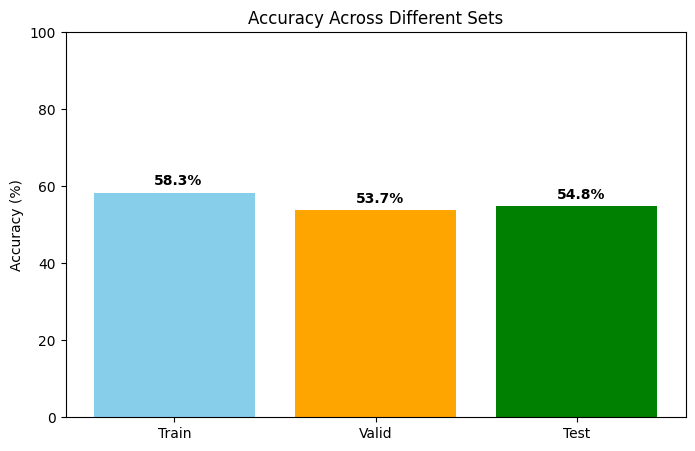


Classification Report (Test Set):

              precision    recall  f1-score   support

           0       0.76      0.57      0.65        93
           1       0.60      0.74      0.66       105
           2       0.51      0.70      0.59        90
           3       0.76      0.41      0.53       100
           4       0.49      0.47      0.48       102
           5       0.36      0.34      0.35        47
           6       0.41      0.28      0.33        83
           7       0.50      0.73      0.59        94

    accuracy                           0.55       714
   macro avg       0.55      0.53      0.52       714
weighted avg       0.56      0.55      0.54       714



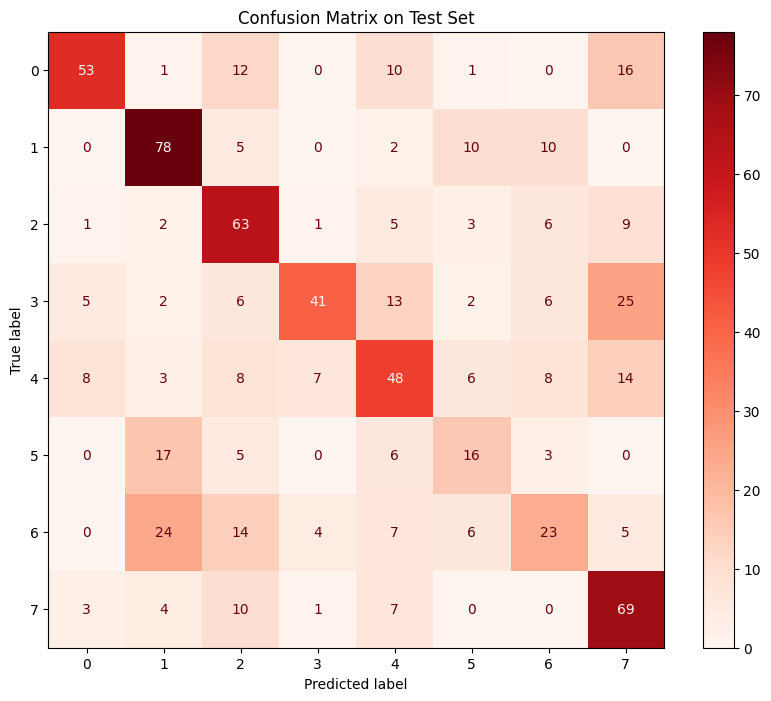

In [ ]:
# 1. Load the best saved weights and set to device
model = CNN(in_channels=3, num_classes=8)
model.load_state_dict(torch.load('bestModel.pth', weights_only=True))
model.to(device)

def get_predictions_and_accuracy(model, loader):
    """Calculates accuracy and collects all predictions/labels for the loader."""
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    accuracy = 100 * correct / total
    return accuracy, all_preds, all_labels

# 2. Calculate Accuracies for all 3 sets
train_acc, _, _ = get_predictions_and_accuracy(model, train_loader)
valid_acc, _, _ = get_predictions_and_accuracy(model, valid_loader)
test_acc, test_preds, test_labels = get_predictions_and_accuracy(model, test_loader)

#Displaying the results

print("Performance:")
print(f"Training Accuracy:{train_acc:.2f}%")
print(f"Validation Accuracy:{valid_acc:.2f}%")
print(f"Test Accuracy:{test_acc:.2f}%")

#Accuracy graph
plt.figure(figsize=(8, 5))
plt.bar(['Train', 'Valid', 'Test'], [train_acc, valid_acc, test_acc], color=['skyblue', 'orange', 'green'])
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Across Different Sets')
plt.ylim(0, 100)
for i, v in enumerate([train_acc, valid_acc, test_acc]):
    plt.text(i - 0.1, v + 2, f"{v:.1f}%", fontweight='bold')
plt.show()

#report
print("\nClassification Report (Test Set):\n")
print(classification_report(test_labels, test_preds))

#confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Reds', ax=plt.gca())
plt.title("Confusion Matrix on Test Set")
plt.show()

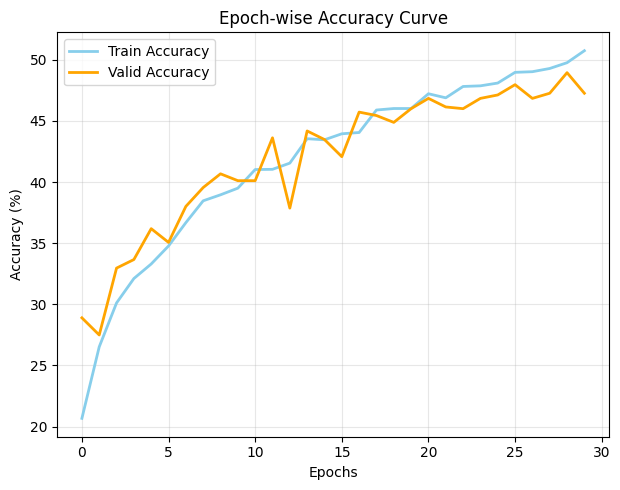

In [ ]:
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy', color='skyblue', linewidth=2)
plt.plot(history['valid_acc'], label='Valid Accuracy', color='orange', linewidth=2)
plt.title('Epoch-wise Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()